# Common

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Any, Callable, List
from scipy.optimize import curve_fit
import sys
from uncertainties import unumpy as unp
import uncertainties as unc

np.set_printoptions(linewidth=200)

In [30]:
# Свинец
d_arr_Pb = unp.uarray([4.5, 5.1, 5.0, 4.9, 5.2, 4.5], [0.1 for _ in range(6)])

# Алюминий
d_arr_Al = unp.uarray([20.9, 20.1, 20.1, 19.6, 19.7, 19.8], [0.1 for _ in range(6)])

# Железо
d_arr_Fe = unp.uarray([10.1, 10.2, 10.1, 10.1, 10.1, 10.2], [0.1 for _ in range(6)])


d_arr_accum_Pb = unp.uarray([], [])
d_arr_accum_Al = unp.uarray([], [])
d_arr_accum_Fe = unp.uarray([], [])

for i in range(6):
    d_i = d_arr_Pb[:(i+1)].sum().n
    d_i_err = d_arr_Pb[:(i+1)].sum().s
    d_arr_accum_Pb = np.append(d_arr_accum_Pb, unp.uarray(d_i, d_i_err))

    d_i = d_arr_Al[:(i+1)].sum().n
    d_i_err = d_arr_Al[:(i+1)].sum().s
    d_arr_accum_Al = np.append(d_arr_accum_Al, unp.uarray(d_i, d_i_err))

    d_i = d_arr_Fe[:(i+1)].sum().n
    d_i_err = d_arr_Fe[:(i+1)].sum().s
    d_arr_accum_Fe = np.append(d_arr_accum_Fe, unp.uarray(d_i, d_i_err))

for i in range(6):
    print(rf'Pb ${d_arr_Pb[:(i+1)].sum().n:.2f} \pm {d_arr_Pb[:(i+1)].sum().s:.2f}$')

print('-'*50)

for i in range(6):
    print(rf'Al ${d_arr_Al[:(i+1)].sum().n:.2f} \pm {d_arr_Al[:(i+1)].sum().s:.2f}$')

print('-'*50)

for i in range(6):
    print(rf'Fe ${d_arr_Fe[:(i+1)].sum().n:.2f} \pm {d_arr_Fe[:(i+1)].sum().s:.2f}$')

print(d_arr_accum_Pb)
print(d_arr_accum_Al)
print(d_arr_accum_Fe)

Pb $4.50 \pm 0.10$
Pb $9.60 \pm 0.14$
Pb $14.60 \pm 0.17$
Pb $19.50 \pm 0.20$
Pb $24.70 \pm 0.22$
Pb $29.20 \pm 0.24$
--------------------------------------------------
Al $20.90 \pm 0.10$
Al $41.00 \pm 0.14$
Al $61.10 \pm 0.17$
Al $80.70 \pm 0.20$
Al $100.40 \pm 0.22$
Al $120.20 \pm 0.24$
--------------------------------------------------
Fe $10.10 \pm 0.10$
Fe $20.30 \pm 0.14$
Fe $30.40 \pm 0.17$
Fe $40.50 \pm 0.20$
Fe $50.60 \pm 0.22$
Fe $60.80 \pm 0.24$
[4.5+/-0.1 9.6+/-0.14142135623730953 14.6+/-0.17320508075688776 19.5+/-0.2 24.7+/-0.223606797749979 29.2+/-0.24494897427831783]
[20.9+/-0.1 41.0+/-0.14142135623730953 61.1+/-0.17320508075688776 80.7+/-0.2 100.4+/-0.223606797749979 120.2+/-0.24494897427831783]
[10.1+/-0.1 20.299999999999997+/-0.14142135623730953 30.4+/-0.17320508075688776 40.5+/-0.2 50.6+/-0.223606797749979 60.8+/-0.24494897427831783]


In [31]:
# --- Класс для параметров стиля ---
@dataclass
class PlotParams:
    """Контейнер для параметров стиля отрисовки."""
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

# --- Класс-обертка для Matplotlib ---
class Plotter:
    """Класс для инкапсуляции всей логики построения графиков."""
    def __init__(self, title: str, xlabel: str, ylabel: str, figsize: tuple = (16, 9)):
        """Инициализирует фигуру и оси, задает основные подписи."""
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает точки."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def add_fit_line(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает сплошную линию (обычно для аппроксимации)."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
        )

    def add_errorbar_points(self, x: np.ndarray, y: np.ndarray,
                            xerr: Optional[np.ndarray], yerr: Optional[np.ndarray],
                            params: PlotParams):
        """Отрисовывает экспериментальные точки с погрешностями."""
        self.ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt=params.marker,
            color=params.color,
            markersize=params.markersize,
            elinewidth=params.linewidth,
            capsize=params.capsize,
            capthick=params.linewidth,
            markevery=params.markevery,
            label=params.label
        )

    def finalize_and_show(self, save_path: Optional[str] = None):
        """Настраивает финальное оформление, сохраняет и/или показывает график."""
        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [32]:
def round_with_uncertainty(value: float, uncertainty: float) -> tuple[float, float]:
    """Округляет значение и погрешность по первой значащей цифре погрешности."""
    if uncertainty == 0 or not np.isfinite(uncertainty) or uncertainty < 1e-12:
        return value, uncertainty
    # Определяем порядок для округления на основе погрешности
    order = -int(np.floor(np.log10(abs(uncertainty))))
    return round(value, order), round(uncertainty, order)

def scale_to_scientific(val: float, sigm: float) -> tuple:
    """
    Рассчитывает компоненты для вывода в научном формате (мантисса, порядок и т.д.).
    Возвращает: (округленные val и sigm, мантиссы, порядок, отн. погрешность).
    """
    val_rounded, sigm_rounded = round_with_uncertainty(val, sigm)
    
    # Расчет относительной погрешности
    if np.isclose(val_rounded, 0):
        varepsilon = float('inf')
    else:
        varepsilon = np.abs(sigm_rounded / val_rounded * 100)

    # Определяем порядок числа для научной нотации
    if np.isclose(val_rounded, 0):
        scale_order = 0
    else:
        # Порядок определяется по абсолютному значению округленной величины
        scale_order = -int(np.floor(np.log10(abs(val_rounded))))

    if scale_order != 0:
        latex_value = val_rounded * 10**scale_order
        latex_uncertainty = sigm_rounded * 10**scale_order
    else:
        latex_value = val_rounded
        latex_uncertainty = sigm_rounded

    return val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon

def print_parameter_report(val: float, sigm: float, parameter_name: str, unit: str = ""):
    """
    Печатает полный отчет по одному параметру.
    Включает сырые данные, округленные и LaTeX-формат с научной нотацией.
    """
    # Получаем все необходимые компоненты
    val_r, sigm_r, lat_val, lat_sigm, order, eps = scale_to_scientific(val, sigm)
    
    # Печатаем отчет
    print(f"------------ {parameter_name} ------------")
    print(f"Raw value     : {val} ± {sigm}")
    print(f"Rounded value : {val_r} ± {sigm_r}")
    
    # Формируем LaTeX строку с учетом порядка
    if order != 0:
        # f-строка с тройными скобками: {{}} для вывода фигурных скобок в LaTeX
        # и {} для подстановки переменной
        if order > 0:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{-{order}}}$ \\ {unit} $(\\varepsilon = {eps:.2f}\\%)$")
        else:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{{-order}}}$ \\ {unit}  $(\\varepsilon = {eps:.2f}\\%)$")
    else:
        print(f"LaTeX: $\\left( {val_r:.4f} \\pm {sigm_r:.4f} \\right)$ \\ {unit},  $(\\varepsilon = {eps:.2f}\\%)$")
    print()

def print_fit_summary(arguments: List[str], popt: np.ndarray, sigm_arr: np.ndarray):
    """
    Печатает сводку по всем результатам аппроксимации.
    """
    print("="*50)
    print("             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ")
    print("="*50)
    for arg, val, sigm in zip(arguments, popt, sigm_arr):
        print_parameter_report(val, sigm, arg)


In [33]:
def load_data(filename: str):
    """Загружает данные из текстового файла."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

def calculate_errors(xdata: np.ndarray, ydata: np.ndarray, config: Dict[str, Any]) -> tuple[np.ndarray, np.ndarray]:
    """
    Гибко вычисляет массивы погрешностей для x и y на основе конфигурационного словаря.
    """
    err_type = config.get('type')
    xerr, yerr = None, None # По умолчанию погрешностей нет

    if err_type == 'absolute':
        xerr = np.full_like(xdata, config.get('x_val', 0))
        yerr = np.full_like(ydata, config.get('y_val', 0))
    elif err_type == 'percent':
        xerr = config.get('x_val', 0) * xdata
        yerr = config.get('y_val', 0) * ydata
    elif err_type == 'custom':
        xerr = config.get('x_err_custom')
        yerr = config.get('y_err_custom')
        
    # Если какой-то из массивов не был создан, заменяем его на массив нулей
    if xerr is None:
        xerr = np.zeros_like(xdata)
    if yerr is None:
        yerr = np.zeros_like(ydata)
        
    return xerr, yerr

In [34]:
def load_data(filename: str):
    """Загружает данные из текстового файла с двумя колонками."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

# Settings

In [35]:
arguments = ['a']
def func_ax(x, a):
    return a * x

# arguments = ['a', 'b']
# def func_axpb(x, a, b):
#     return a * x + b

# arguments = ['a', 'b', 'c', 'd']
# def polinomial_func(x, a, b, c, d):
#     return a * x**3 + b * x**2 + c * x + d

# arguments = ['y0', 'power', 'bias']
# def exponential_func(x, y0, power, bias):
#     return y0 * np.exp(power * x) + bias

In [36]:
func = func_ax

# Changable parameters

In [37]:
# Common

# background
N_bg = unc.ufloat(26.93571428571420, 0.27998555734267)

# No absorber
N_0 = unc.ufloat(18650.7444444444, 66.7169958171394)

N_0_no_bg = N_0 - N_bg

In [38]:
# Свинец
N_diff_width_Pb = unp.uarray([10999.1111111111, 
                              6249.08, 
                              3468.4, 
                              2042.32222222222,
                              1195.31666666666,
                              794.483333333333], 
                              
                              [32.1194491289261, 
                               18.662218517636, 
                               5.55187655962688, 
                               6.20557047645672,
                               2.76916553816808,
                               2.05319534168357])

N_diff_width_no_bg_Pb = N_diff_width_Pb - N_bg
y_Pb = unp.log(N_0_no_bg / N_diff_width_no_bg_Pb)

# Алюминий
N_diff_width_Al = unp.uarray([12195.6333333333, 
                              8116.09999999999, 
                              5396.75, 
                              3689.55,
                              2484.825,
                              1683.61999999999], 
                              
                              [5.81731133008304, 
                               19.971980372512, 
                               14.9033273689692, 
                               7.8882296281654,
                               2.3478270095274,
                               4.2499882352778])

N_diff_width_no_bg_Al = N_diff_width_Al - N_bg
y_Al = unp.log(N_0_no_bg / N_diff_width_no_bg_Al)

# Железо
N_diff_width_Fe = unp.uarray([10352.7, 
                              5838.49999999999, 
                              3330.18333333333, 
                              1923.2,
                              1122.93333333333,
                              666.988888888888], 
                              
                              [15.6885839598946, 
                               14.5840666482294, 
                               6.50453260768551, 
                               4.97721474990448,
                               3.84606581095827,
                               2.75834312407348])

N_diff_width_no_bg_Fe = N_diff_width_Fe - N_bg
y_Fe = unp.log(N_0_no_bg / N_diff_width_no_bg_Fe)

In [39]:
# (0 --- np.inf)
# error_config = \
# {
#     'type': 'absolute', 
#     'x_val': 0.01, 
#     'y_val': 0.2
# }

# # (0 --- 1)
# error_config = \
# {
#     'type': 'percent', 
#     'x_val': 0.05, 
#     'y_val': 0.1
# }

# # User errors
# error_config = \
# {
#     'type': 'custom', 
#     'x_err_custom': np.full_like(I_data, 0.02), 
#     'y_err_custom': error_N_net,
# }

In [40]:
# User errors
error_config_Pb = \
{
    'type': 'custom', 
    'x_err_custom': unp.std_devs(d_arr_accum_Pb), 
    'y_err_custom': unp.std_devs(y_Pb),
}

error_config_Al = \
{
    'type': 'custom', 
    'x_err_custom': unp.std_devs(d_arr_accum_Al), 
    'y_err_custom': unp.std_devs(y_Al),
}

error_config_Fe = \
{
    'type': 'custom', 
    'x_err_custom': unp.std_devs(d_arr_accum_Fe), 
    'y_err_custom': unp.std_devs(y_Fe),
}

# Run

In [41]:
# filename = 'data.txt'
# x, y = load_data(filename)

In [42]:
unp.std_devs(d_arr_accum_Pb) / unp.nominal_values(d_arr_accum_Pb) * 100

array([2.22222222, 1.47313913, 1.18633617, 1.02564103, 0.90529068, 0.83886635])

In [43]:
unp.std_devs(y_Pb) / unp.nominal_values(y_Pb) * 100

array([0.87440943, 0.42617474, 0.23270908, 0.21250845, 0.15534687, 0.14062587])

In [44]:
# 2. Расчет погрешностей
xerr_Pb, yerr_Pb = calculate_errors(unp.nominal_values(d_arr_accum_Pb), unp.nominal_values(y_Pb), error_config_Pb)
xerr_Al, yerr_Al = calculate_errors(unp.nominal_values(d_arr_accum_Al), unp.nominal_values(y_Al), error_config_Al)
xerr_Fe, yerr_Fe = calculate_errors(unp.nominal_values(d_arr_accum_Fe), unp.nominal_values(y_Fe), error_config_Fe)

# 3. Аппроксимация
popt_Pb, pcov_Pb = curve_fit(func, unp.nominal_values(d_arr_accum_Pb), unp.nominal_values(y_Pb), sigma=yerr_Pb)
popt_Al, pcov_Al = curve_fit(func, unp.nominal_values(d_arr_accum_Al), unp.nominal_values(y_Al), sigma=yerr_Al)
popt_Fe, pcov_Fe = curve_fit(func, unp.nominal_values(d_arr_accum_Fe), unp.nominal_values(y_Fe), sigma=yerr_Fe)

# 4. Вывод результатов
print_fit_summary(arguments, popt_Pb, np.sqrt(np.diag(pcov_Pb)))
print_fit_summary(arguments, popt_Al, np.sqrt(np.diag(pcov_Al)))
print_fit_summary(arguments, popt_Fe, np.sqrt(np.diag(pcov_Fe)))

# # Извлечем нужные параметры для дальнейших расчетов
# a, b = popt

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : 0.11186220115911101 ± 0.0010654582239409964
Rounded value : 0.112 ± 0.001
LaTeX: $\left( 1.120 \pm 0.010 \right) \cdot 10^{-1}$ \  $(\varepsilon = 0.89\%)$

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : 0.020178832320883102 ± 3.2119419003674674e-05
Rounded value : 0.02018 ± 3e-05
LaTeX: $\left( 2.018 \pm 0.003 \right) \cdot 10^{-2}$ \  $(\varepsilon = 0.15\%)$

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : 0.05615972568736308 ± 0.0002918719251287444
Rounded value : 0.0562 ± 0.0003
LaTeX: $\left( 5.620 \pm 0.030 \right) \cdot 10^{-2}$ \  $(\varepsilon = 0.53\%)$



In [56]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict_Pb = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="red", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

plot_args_dict_Al = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="red", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

plot_args_dict_Fe = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="red", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

График сохранен в файл: Pb.pdf


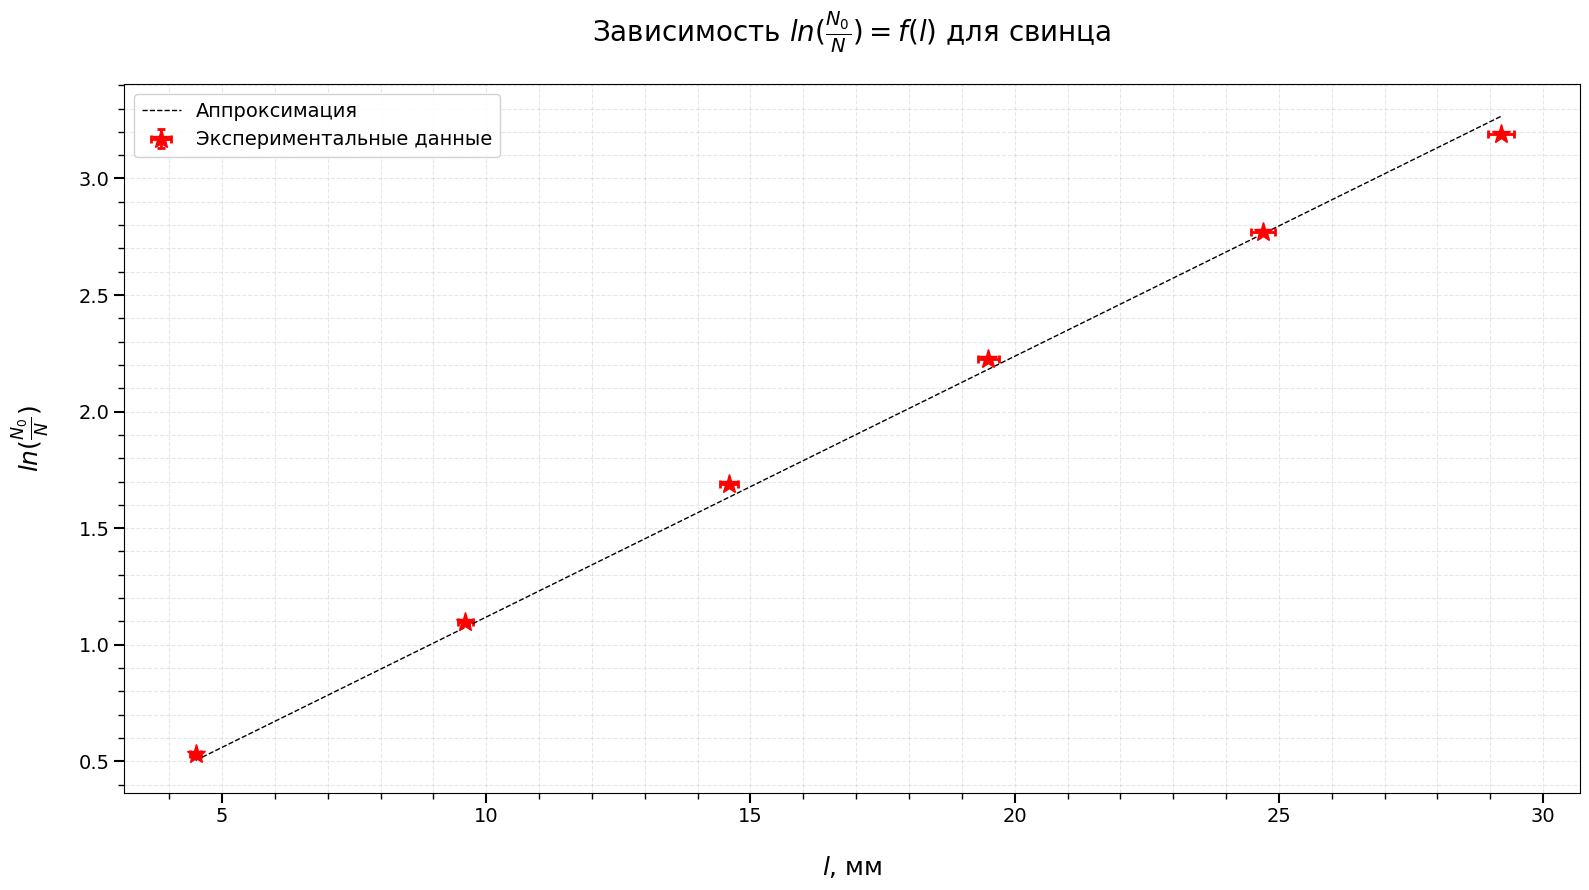

График сохранен в файл: Al.pdf


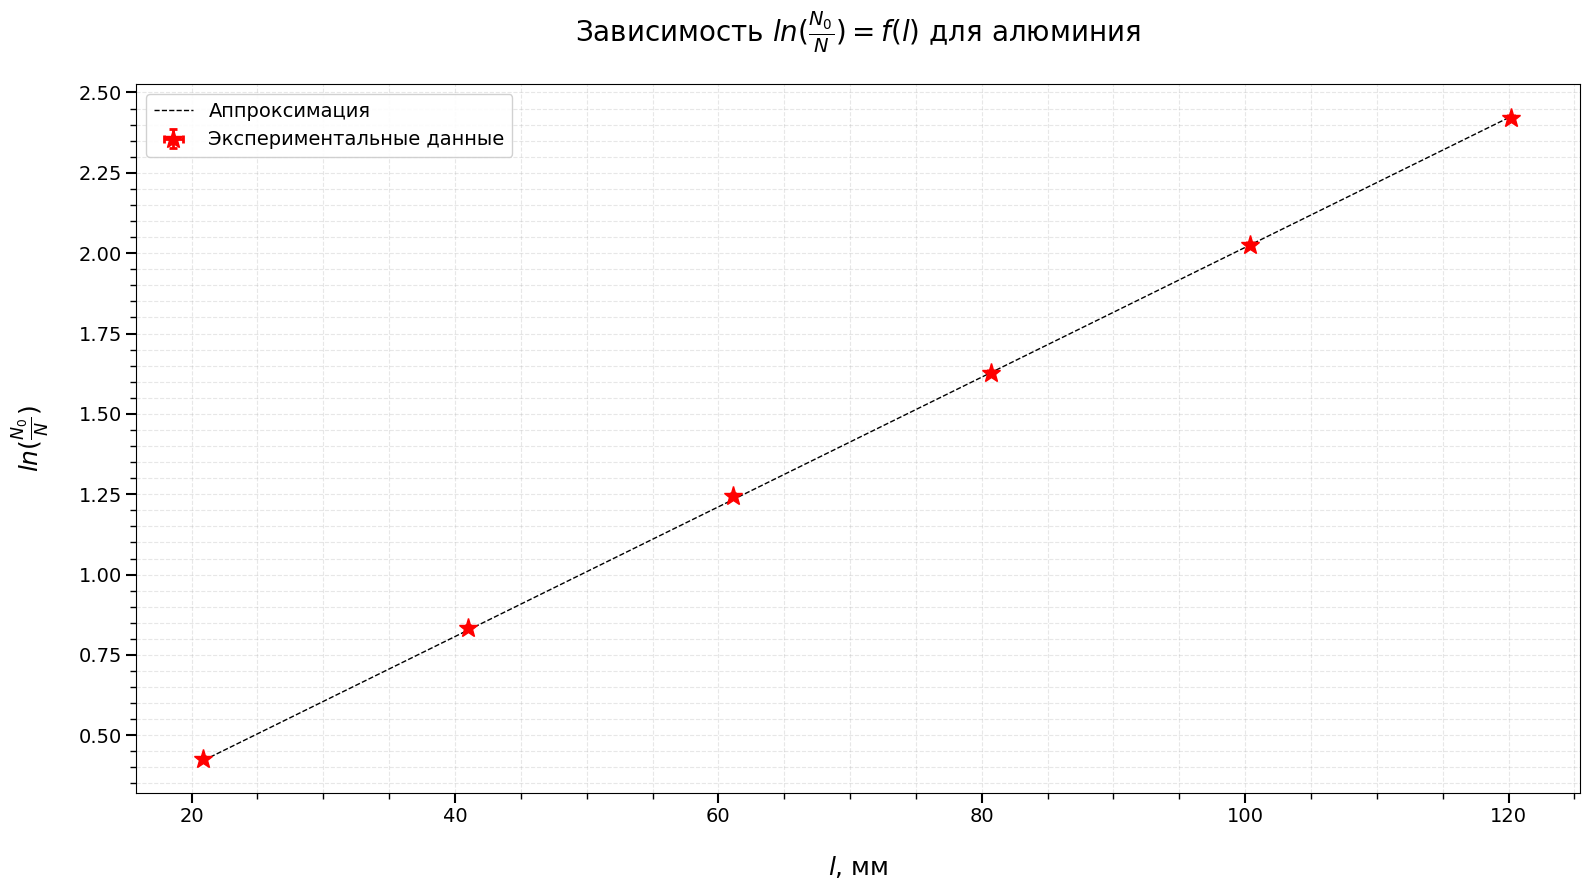

График сохранен в файл: Fe.pdf


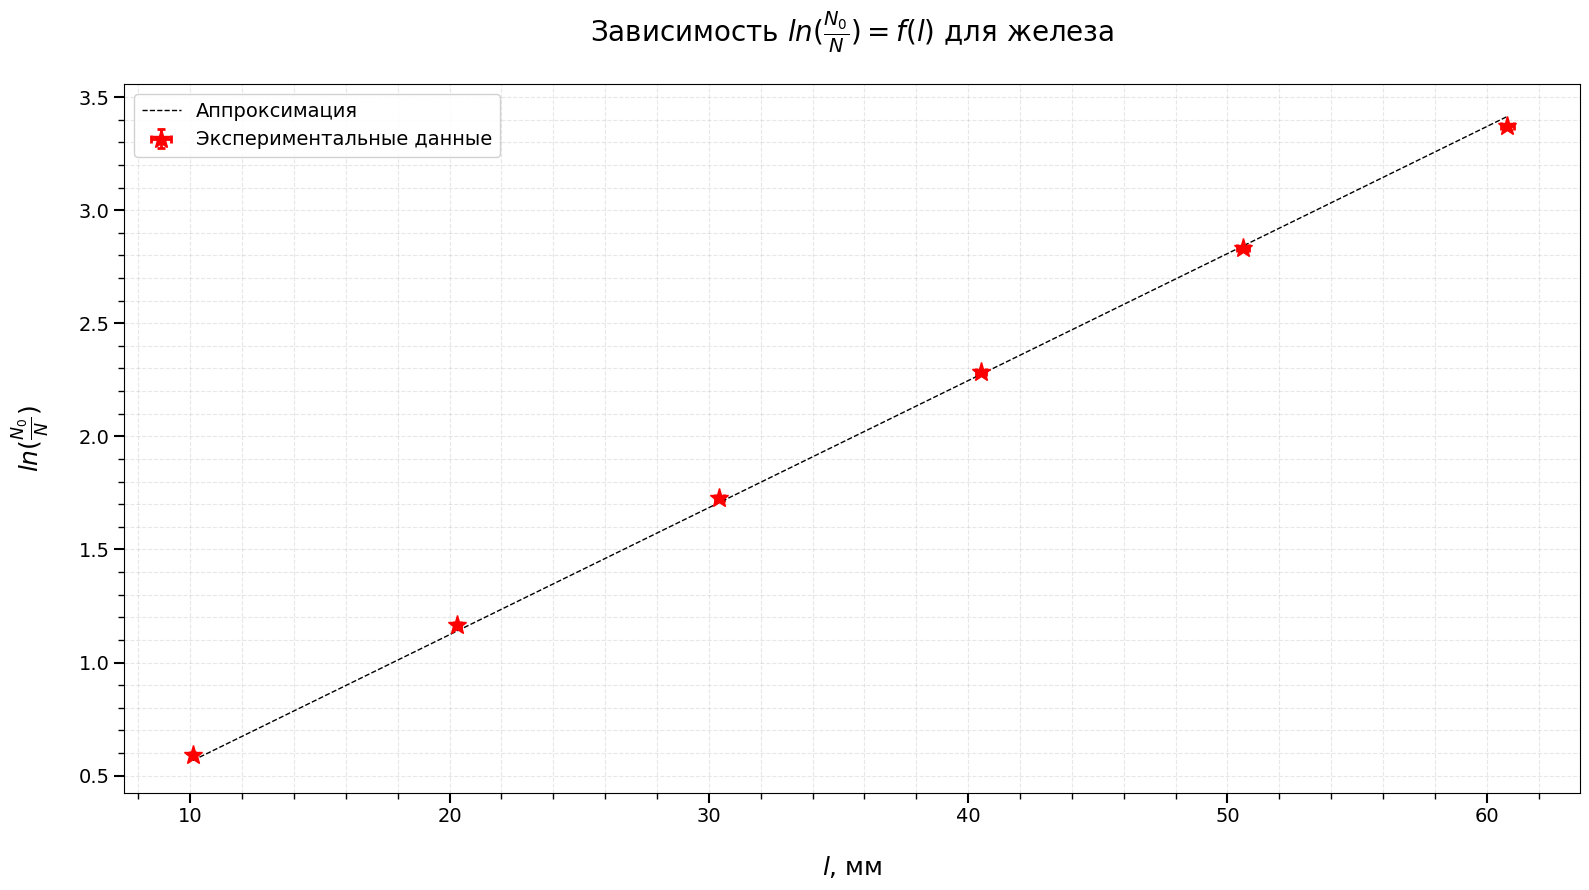

In [57]:
# --- 2. Построение графика ---

# Свинец
plotter_Pb = Plotter(
    title=r'Зависимость $ln(\frac{N_0}{N}) = f(l)$ для свинца',
    xlabel=r'$l$, мм',
    ylabel=r'$ln(\frac{N_0}{N})$'
)
# Добавляем экспериментальные точки
plotter_Pb.add_errorbar_points(unp.nominal_values(d_arr_accum_Pb), unp.nominal_values(y_Pb), xerr=xerr_Pb, yerr=yerr_Pb, params=plot_args_dict_Pb['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth_Pb = np.linspace(unp.nominal_values(d_arr_accum_Pb).min(), unp.nominal_values(d_arr_accum_Pb).max(), 500)
y_fit_Pb = func(x_smooth_Pb, *popt_Pb)

plotter_Pb.add_fit_line(x_smooth_Pb, y_fit_Pb, params=plot_args_dict_Pb['Fitted'])

# Финализируем и показываем график
plotter_Pb.finalize_and_show("Pb.pdf")


# Алюминий
plotter_Al = Plotter(
    title=r'Зависимость $ln(\frac{N_0}{N}) = f(l)$ для алюминия',
    xlabel=r'$l$, мм',
    ylabel=r'$ln(\frac{N_0}{N})$'
)

# Добавляем экспериментальные точки
plotter_Al.add_errorbar_points(unp.nominal_values(d_arr_accum_Al), unp.nominal_values(y_Al), xerr=xerr_Al, yerr=yerr_Al, params=plot_args_dict_Al['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth_Al = np.linspace(unp.nominal_values(d_arr_accum_Al).min(), unp.nominal_values(d_arr_accum_Al).max(), 500)
y_fit_Al = func(x_smooth_Al, *popt_Al)

plotter_Al.add_fit_line(x_smooth_Al, y_fit_Al, params=plot_args_dict_Al['Fitted'])

# Финализируем и показываем график
plotter_Al.finalize_and_show("Al.pdf")

# Железо
plotter_Fe = Plotter(
    title=r'Зависимость $ln(\frac{N_0}{N}) = f(l)$ для железа',
    xlabel=r'$l$, мм',
    ylabel=r'$ln(\frac{N_0}{N})$'
)
# Добавляем экспериментальные точки
plotter_Fe.add_errorbar_points(unp.nominal_values(d_arr_accum_Fe), unp.nominal_values(y_Fe), xerr=xerr_Fe, yerr=yerr_Fe, params=plot_args_dict_Fe['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth_Fe = np.linspace(unp.nominal_values(d_arr_accum_Fe).min(), unp.nominal_values(d_arr_accum_Fe).max(), 500)
y_fit_Fe = func(x_smooth_Fe, *popt_Fe)

plotter_Fe.add_fit_line(x_smooth_Fe, y_fit_Fe, params=plot_args_dict_Fe['Fitted'])

# Финализируем и показываем график
plotter_Fe.finalize_and_show("Fe.pdf")